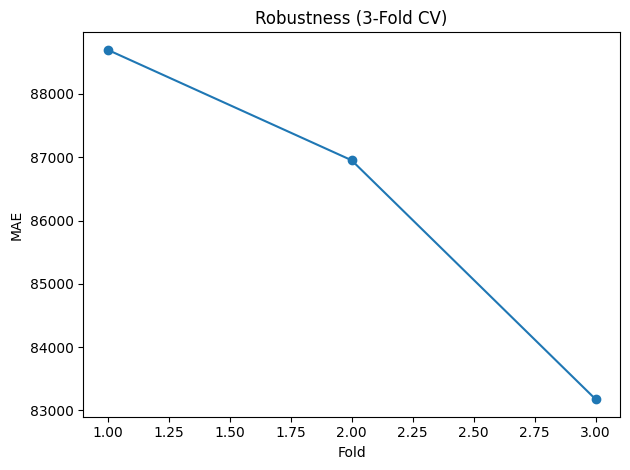

In [1]:
# =========================
# RQ6: Robustness (FAST VERSION)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

DATA_PATH = "/kaggle/input/datasets/alyelbadry/house-pricing-dataset/house_prices.csv"

# Load and reduce size
df = pd.read_csv(DATA_PATH).dropna()
df = df.sample(n=5000, random_state=42)  # 🔥 speed boost

X = pd.get_dummies(df.drop("price", axis=1))
y = df["price"]

# Faster model
model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

# Faster CV
scores = cross_val_score(
    model,
    X,
    y,
    cv=3,  # 🔥 reduced folds
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

mae_scores = -scores

# Save table
table = pd.DataFrame({
    "Fold": range(1, len(mae_scores)+1),
    "MAE": mae_scores
})
table.to_csv("RQ6_table.csv", index=False)

# Plot
plt.figure()
plt.plot(table["Fold"], table["MAE"], marker='o')
plt.title("Robustness (3-Fold CV)")
plt.xlabel("Fold")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig("RQ6_figure.pdf")
plt.show()